In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(os.path.abspath("..")) 
from prokaryotic.functional import categorize_functional_shifts, is_informative

ORGANISMS = {
    "bacillus": "B. subtilis",
    "e_coli": "E. coli"
}
TOOLS_TO_EVALUATE = ['Prokka', 'Bakta', 'PGAP', 'eggNOG']

COLOR_MAP = {
    'Both Informative': '#66c2a5', 
    'Both Hypothetical': '#fc8d62', 
    'Over-Annotation': '#8da0cb',  
    'Under-Annotation': '#e78ac3'    
}

In [2]:
print("Ground Truth Base Rates")
print("=======================\n")

for org_id, org_name in ORGANISMS.items():
    input_csv = f"{org_id}_data/{org_id}_concordant_CDS.csv"
    if not os.path.exists(input_csv):
        print(f"Skipping {org_name} - {input_csv} not found.")
        continue

    df_func = pd.read_csv(input_csv)
    total = len(df_func)
    informative = df_func["product_Reference"].apply(is_informative).sum()
    non_informative = total - informative

    print(f"{org_name} (n = {total} CDS):")
    print(f"  Informative:       {informative:>4} ({informative/total*100:.1f}%)")
    print(f"  Non-informative:   {non_informative:>4} ({non_informative/total*100:.1f}%)")
    print()

Ground Truth Base Rates

B. subtilis (n = 4240 CDS):
  Informative:       2453 (57.9%)
  Non-informative:   1787 (42.1%)

E. coli (n = 4340 CDS):
  Informative:       3348 (77.1%)
  Non-informative:    992 (22.9%)




  Product description plot: B. subtilis



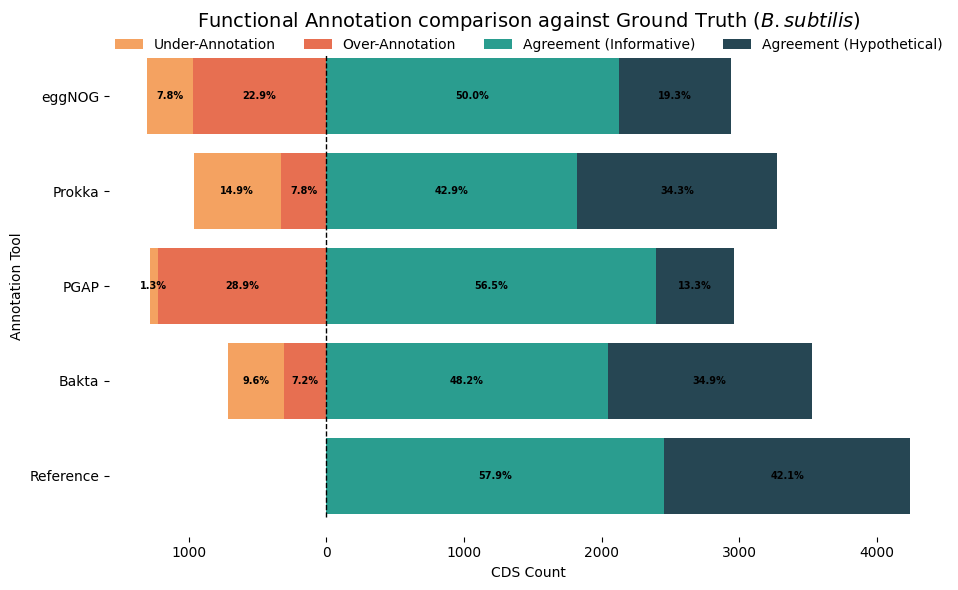


  Product description plot: E. coli



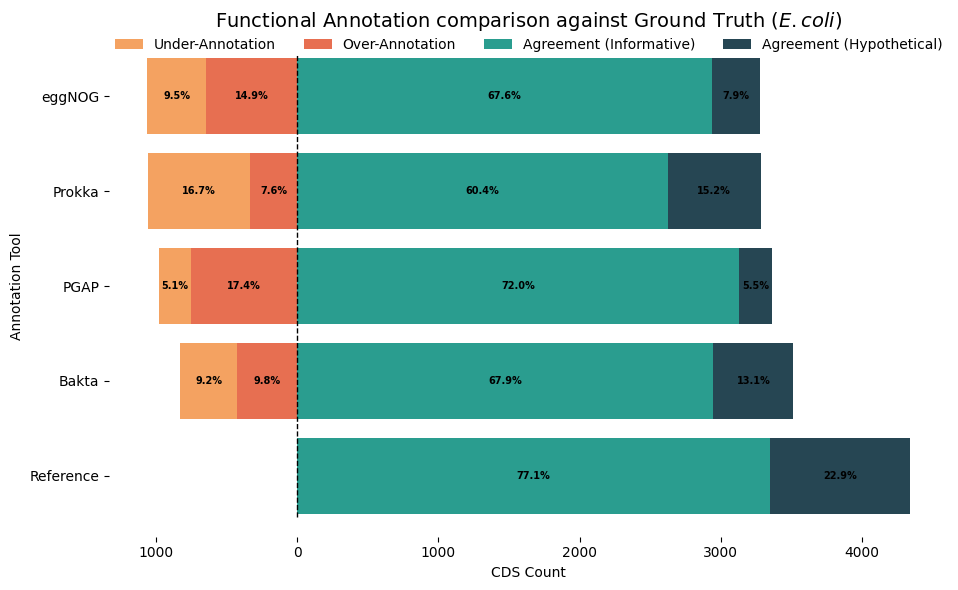

In [3]:
for org_id, org_name in ORGANISMS.items():
    print("\n=========================================")
    print(f"  Product description plot: {org_name}")
    print("=========================================\n")

    input_csv = f"{org_id}_data/{org_id}_concordant_CDS.csv"
    if not os.path.exists(input_csv):
        print(f"Skipping {org_name} - {input_csv} not found.")
        continue

    df_func = pd.read_csv(input_csv)
    summary_table = categorize_functional_shifts(df_func, tools=TOOLS_TO_EVALUATE)

    total = summary_table.sum(axis=1).iloc[0]
    ref_info = df_func["product_Reference"].apply(is_informative).sum()
    ref_non_info = total - ref_info

    ref_row = pd.DataFrame({
        "Both Informative": [ref_info],
        "Both Hypothetical": [ref_non_info],
        "Over-Annotation": [0],
        "Under-Annotation": [0]
    }, index=["Reference"])

    plot_df = pd.concat([ref_row, summary_table])

    plot_df["Over-Annotation"] = -plot_df["Over-Annotation"]
    plot_df["Under-Annotation"] = -plot_df["Under-Annotation"]

    fig, ax = plt.subplots(figsize=(10,6))

    ax.barh(
        plot_df.index,
        plot_df["Over-Annotation"],
        color="#e76f51",
        label="Over-Annotation"
    )

    ax.barh(
        plot_df.index,
        plot_df["Under-Annotation"],
        left=plot_df["Over-Annotation"],
        color="#f4a261",
        label="Under-Annotation"
    )

    ax.barh(
        plot_df.index,
        plot_df["Both Informative"],
        color="#2a9d8f",
        label="Agreement (Informative)"
    )

    ax.barh(
        plot_df.index,
        plot_df["Both Hypothetical"],
        left=plot_df["Both Informative"],
        color="#264653",
        label="Agreement (Hypothetical)"
    )

    ax.axvline(0, color="black", linewidth=1, linestyle='--',ymax=0.96, ymin=0.04)

    
    for spine in ax.spines.values():
        spine.set_visible(False)
    for container in ax.containers:
        labels = [f'{abs(v)/total*100:.1f}%' if v != 0 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=7, fontweight='bold')

    ax.set_xlabel("CDS Count")
    ax.set_ylabel("Annotation Tool")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(abs(x))}'))
    
    plt.title(f"Functional Annotation comparison against Ground Truth ($\\mathit{{{org_name}}}$)", fontsize=14)
    handles, labels = ax.get_legend_handles_labels()

    order = [1, 0, 2, 3]  

    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        frameon=False
    )


    plt.tight_layout()
    plt.show()